# Demonstration: Urban Flight

```
Copyright © 2024, United States Government, as represented by the Administrator of the National Aeronautics and Space Administration. All rights reserved.

The “"Fault Model Design tools - fmdtools version 2"” software is licensed under the Apache License, Version 2.0 (the "License"); you may not use this file except in compliance with the License. You may obtain a copy of the License at http://www.apache.org/licenses/LICENSE-2.0. 

Unless required by applicable law or agreed to in writing, software distributed under the License is distributed on an "AS IS" BASIS, WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied. See the License for the specific language governing permissions and limitations under the License.
```

In [1]:
import fmdtools.sim.propagate as propagate
from fmdtools.analyze import tabulate

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
import numpy as np

Matplotlib is building the font cache; this may take a moment.


## Model Overview

The urban flight drone represents a drone flying over an urban area with buildings and places to land (or not land).

This drone model variant is defined in `model_urban.py`, along with some visualization functions.

In [2]:
from model_urban import Drone

In [3]:
mdl = Drone(sp={'end_condition': 'scenario_finished'})
mdl

drone Drone
- t=Time(time=-0.1, timers={})
- m=Mode(mode='nominal', faults=set(), sub_faults=False)
FLOWS:
- force_st=Force(s=(support=1.0))
- force_lin=Force(s=(support=1.0))
- hsig_dofs=HSig(s=(hstate='nominal'))
- hsig_bat=HSig(s=(hstate='nominal'))
- rsig_traj=RSig(s=(mode='continue'))
- ee_1=EE(s=(rate=1.0, effort=1.0))
- ee_mot=EE(s=(rate=1.0, effort=1.0))
- ee_ctl=EE(s=(rate=1.0, effort=1.0))
- ctl=Control(s=(forward=1.0, upward=1.0))
- dofs=DOFs(s=(vertvel=1.0, planvel=1.0, planpwr=1.0, uppwr=1.0, x=0.0, y=0.0, z=0.0))
- des_traj=DesTraj(s=(dx=1.0, dy=0.0, dz=0.0, power=1.0))
- environment=UrbanDroneEnvironment(s=(safe=True, allowed=True, landed=True, occupied=False), c=(), ga=())
FXNS:
- manage_health=ManageHealth(m=(mode='nominal', faults=set(), sub_faults=False))
- store_ee=StoreEE(s=(soc=100.0), m=(mode='nominal', faults=set(), sub_faults=False))
- dist_ee=DistEE(s=(ee_tr=1.0, ee_te=1.0), m=(mode='nominal', faults=set(), sub_faults=False))
- affect_dof=AffectDOF(s=(e_to=1.0

This is the model structure:

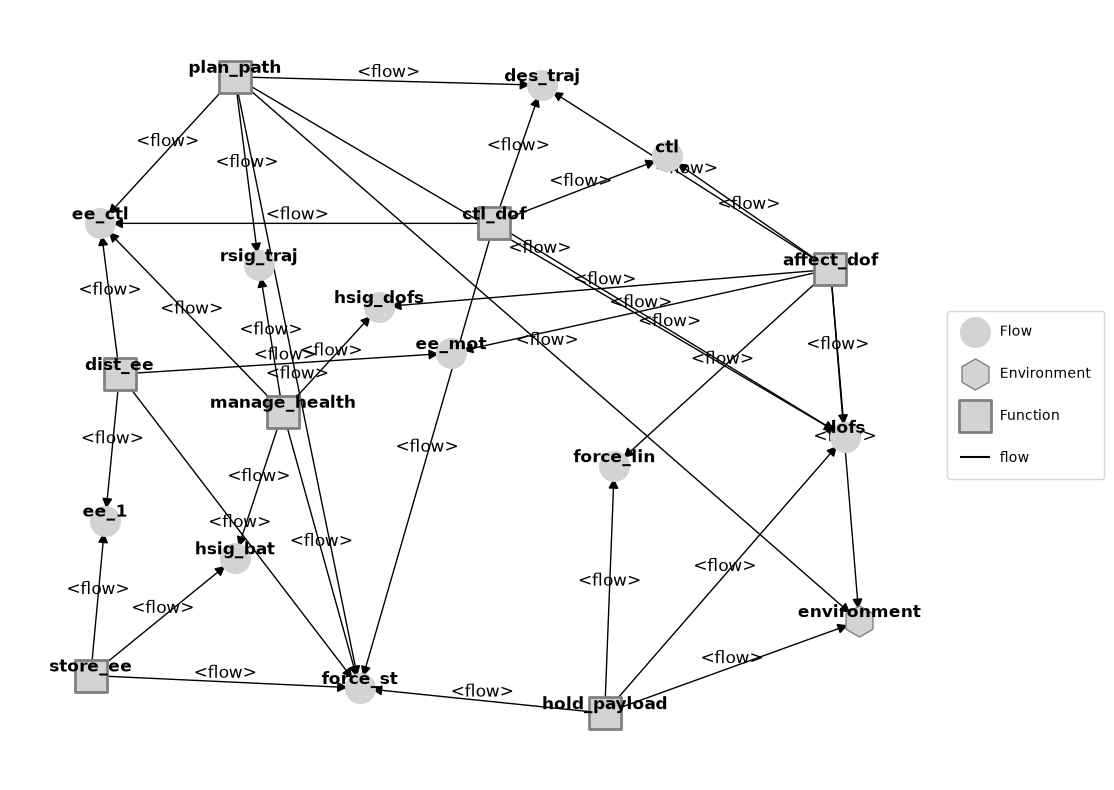

In [4]:
from model_static import pos
mg = mdl.as_modelgraph()
pos = {**pos, **{'drone.flows.environment': [0.75, -0.5], 'drone.flows.rsig_traj': [-0.5, 0.35], 'drone.flows.hsig_dofs': [-0.25, 0.25], 'drone.flows.hsig_bat': [-0.55, -0.35], 'drone.fxns.manage_health': [-0.45, 0.0]}}
mg.set_pos(**pos)
fig, ax = mg.draw()

We can also view the grid environment using its `show` methods:

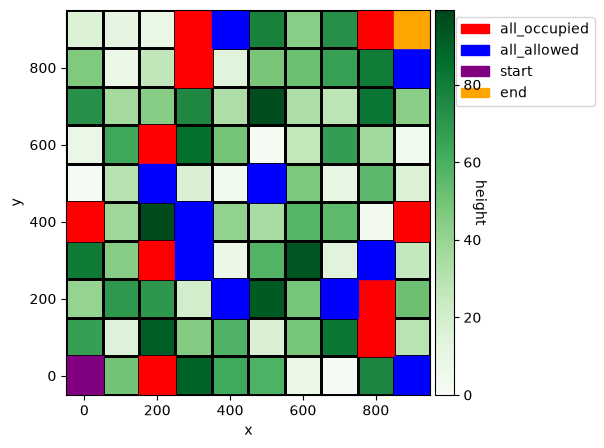

In [5]:
collections={"all_occupied": {"color": "red"}, "all_allowed": {"color": "blue"}, "start": {"color": "purple"}, "end": {"color": "orange"}}
fig, ax = mdl.flows['environment'].c.show({"height": {}}, collections=collections)

Which shows the Start, End, and allowed/unsafe locations in the 1000x1000-m grid. In this display, line thickness corresponds to building height, and hatching corresponds to whether or not the space is occupied. We can also display this using `show.coord3d`:

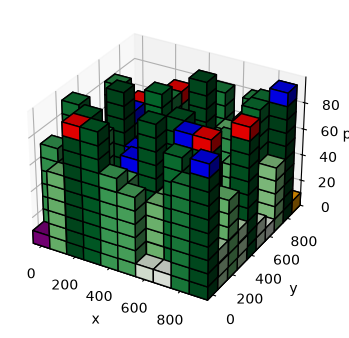

In [6]:
fig, ax = mdl.flows['environment'].c.show_z("height", collections=collections)

## Nominal Simulation

Below we show how this drone performs in the nominal scenario.

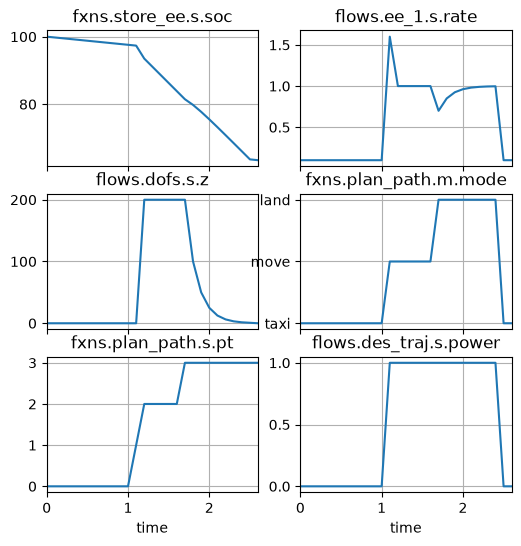

In [7]:
results_nom, hist_nom = propagate.nominal(mdl)
fig, axs = hist_nom.plot_line("fxns.store_ee.s.soc",
                            'flows.ee_1.s.rate',
                            'flows.dofs.s.z',
                            'fxns.plan_path.m.mode',
                            'fxns.plan_path.s.pt',
                            'flows.des_traj.s.power')

As shown, the flight ends fairly quickly (in 2.5 minutes), with the drone successively proceeding through points in the flight plan.

We can also view this flightpath in 3-d space using `History.plot_trajectories`:

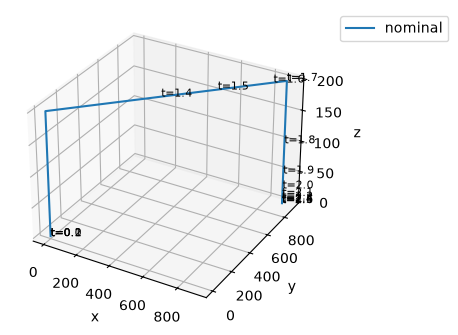

In [8]:
fig, ax = hist_nom.plot_trajectories('dofs.s.x', 'dofs.s.y', 'dofs.s.z', time_groups=['nominal'], time_ticks=0.1)

Trajectory plots can be overlaid on top of environment plots. In this case, we defined the method `plot_env_with_traj` and `plot_env_with_traj_z` for this case.

In [9]:
from model_urban import plot_env_with_traj, plot_env_with_traj_z


(<Figure size 400x400 with 1 Axes>,
 <Axes3D: title={'center': 'trajectory'}, xlabel='x', ylabel='y', zlabel='z'>)

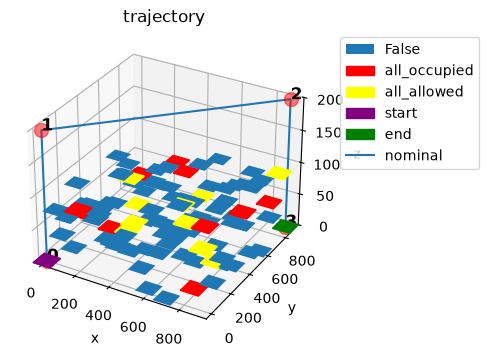

In [10]:
plot_env_with_traj_z(hist_nom, mdl)

(<Figure size 500x500 with 2 Axes>,
 <Axes: title={'center': 'trajectory'}, xlabel='x', ylabel='y'>)

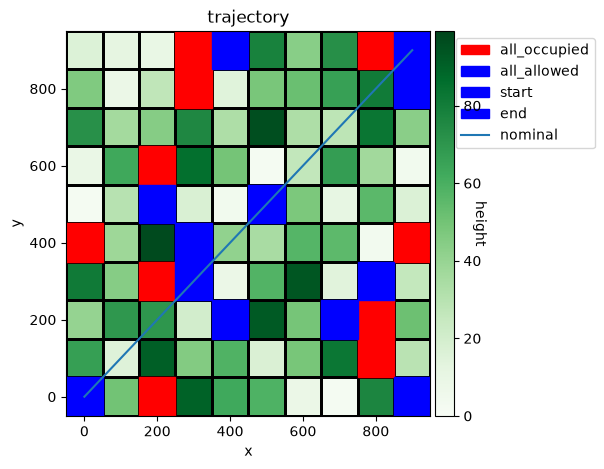

In [11]:
plot_env_with_traj(hist_nom, mdl)

As shown, this is a rather simple straight-line path where the drone flies at full speed. If we wanted a more complex scenario, we could make the path more complex by adding multiple destinations or planning the path based on allowed flight/landing locations.

As it is, we may also want to adjust the timestep/speed to get more resolution, since the drone only has a few discrete timesteps in the air.

The results for the simulation are:

In [12]:
results_nom

tend.classify.rate:                  1.0
tend.classify.cost:                  0.0
tend.classify.expected_cost:         0.0
tend.classify.repcost:                 0
tend.classify.unsafe_flight_time:    0.0
tend.classify.body_strikes:          0.0
tend.classify.head_strikes:          0.0
tend.classify.property_restrictions:   0
tend.classify.safecost:              0.0
tend.classify.landcost:                0
tend.classify.p_safety:              0.0
tend.classify.severities.hazardous:  0.0
tend.classify.severities.minor:      1.0

## Resilience model

A number of different fault modes have been set up in the model to allow us to simulate various hazardous behaviors.

In [13]:
mdl.fxns['affect_dof'].get_faults(only_present=False)

{'drone.fxns.affect_dof': {},
 'drone.fxns.affect_dof.ca': {},
 'drone.fxns.affect_dof.ca.comps.lf': {'ctlbreak': Fault(prob=2.0000000000000003e-06, cost=1000.0, phases=(), disturbances=(), units=sim),
  'ctldn': Fault(prob=2.0000000000000003e-06, cost=500.0, phases=(), disturbances=(), units=sim),
  'ctlup': Fault(prob=2.0000000000000003e-06, cost=500.0, phases=(), disturbances=(), units=sim),
  'mechbreak': Fault(prob=1.0000000000000002e-06, cost=500.0, phases=(), disturbances=(), units=sim),
  'mechfriction': Fault(prob=5.000000000000001e-07, cost=500.0, phases=(), disturbances=(), units=sim),
  'openc': Fault(prob=1.0000000000000002e-06, cost=200.0, phases=(), disturbances=(), units=sim),
  'propbreak': Fault(prob=3.0000000000000004e-07, cost=200.0, phases=(), disturbances=(), units=sim),
  'propstuck': Fault(prob=2.0000000000000002e-07, cost=200.0, phases=(), disturbances=(), units=sim),
  'propwarp': Fault(prob=1.0000000000000001e-07, cost=200.0, phases=(), disturbances=(), units

For example, here we inject a mechanical fault in the left-rear rotor during flight:

In [14]:
results_fault, hist_fault = propagate.one_fault(mdl, "affect_dof.ca.comps.lr", "mechbreak", time=1.4)

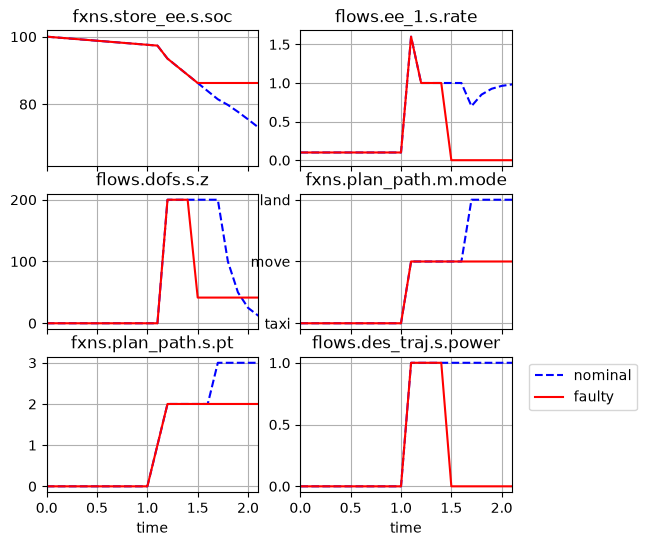

In [15]:
fig, axs = hist_fault.plot_line("fxns.store_ee.s.soc",
                                'flows.ee_1.s.rate',
                                'flows.dofs.s.z',
                                'fxns.plan_path.m.mode',
                                'fxns.plan_path.s.pt',
                                'flows.des_traj.s.power')

(<Figure size 400x400 with 1 Axes>,
 <Axes3D: title={'center': 'trajectory'}, xlabel='x', ylabel='y', zlabel='z'>)

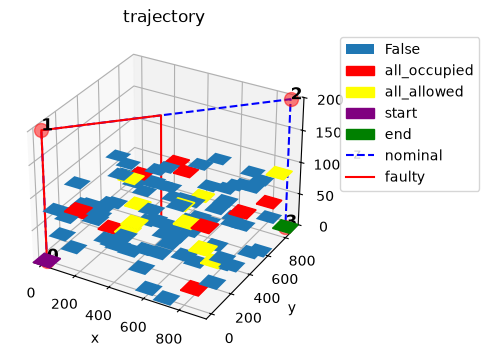

In [16]:
plot_env_with_traj_z(hist_fault, mdl)

(<Figure size 500x500 with 2 Axes>,
 <Axes: title={'center': 'trajectory'}, xlabel='x', ylabel='y'>)

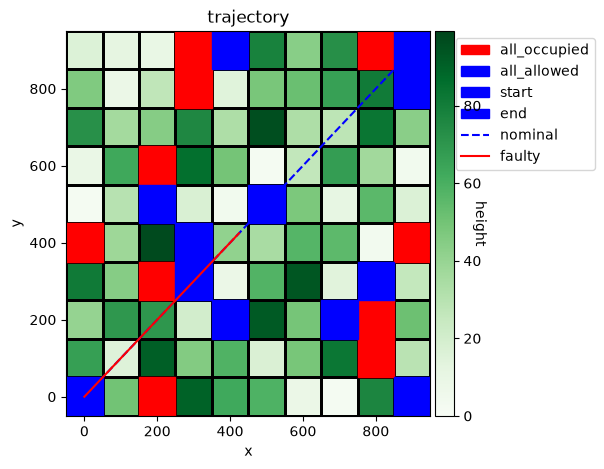

In [17]:
plot_env_with_traj(hist_fault, mdl)

In [18]:
results_fault.faulty

tend.classify.rate: 1.0000000000000002e-06
tend.classify.cost:               1580.0
tend.classify.expected_cost: 158.00000000000003
tend.classify.repcost:            1500.0
tend.classify.unsafe_flight_time:    0.8
tend.classify.body_strikes:          0.0
tend.classify.head_strikes:          0.0
tend.classify.property_restrictions:   0
tend.classify.safecost:             80.0
tend.classify.landcost:                0
tend.classify.p_safety:              0.0
tend.classify.severities.hazardous:  0.0
tend.classify.severities.minor: 1.0000000000000002e-06

## Systematic Fault Injection

Here we inject a large list of faults in the system and evaluate their relative consequences in terms of metrics calculated in classify:

In [19]:
from fmdtools.analyze.phases import PhaseMap, from_hist
phasemaps = from_hist(hist_nom, fxn_modephases=[], dt=mdl.sp.dt)
phasemaps['plan_path']

PhaseMap({np.str_('taxi'): [np.float64(0.0), np.float64(1.0)], np.str_('move'): [np.float64(1.1), np.float64(1.6)], np.str_('land'): [np.float64(1.7), np.float64(2.4)], 'taxi1': [np.float64(2.5), np.float64(2.6)]}, {})

In [20]:
from model_urban import make_move_quad
move_quad=make_move_quad(hist_nom, phasemaps['plan_path'].phases['move'])
move_quad

{'samp': 'quadrature',
 'quad': {'nodes': [np.float64(-0.20000000000000018),
   np.float64(0.1999999999999993)],
  'weights': [0.006, 1.0]}}

Constructing the fault domain:

In [21]:
from fmdtools.sim.sample import FaultDomain, FaultSample

fd = FaultDomain(mdl)
fd.add_all_fxn_modes(*[f for f in mdl.fxns if f not in ['affect_dof', 'store_ee']])
fd.add_singlecomp_modes()
fd

FaultDomain with faults:
 -('drone.fxns.manage_health', 'lostfunction')
 -('drone.fxns.dist_ee', 'break')
 -('drone.fxns.dist_ee', 'degr')
 -('drone.fxns.dist_ee', 'short')
 -('drone.fxns.ctl_dof', 'degctl')
 -('drone.fxns.ctl_dof', 'noctl')
 -('drone.fxns.plan_path', 'degloc')
 -('drone.fxns.plan_path', 'noloc')
 -('drone.fxns.plan_path.ca.comps.vision', 'lack_of_detection')
 -('drone.fxns.plan_path.ca.comps.vision', 'undesired_detection')
 -...more

Sampling the fault domain:

In [22]:
fs = FaultSample(fd, phasemap = phasemaps['plan_path'])
fs.add_fault_phases("move", method = "quad",
                    args=(move_quad['quad']['nodes'], move_quad['quad']['weights']))

fs

FaultSample of scenarios: 
 - drone_fxns_manage_health_lostfunction_t1p3
 - drone_fxns_manage_health_lostfunction_t1p4
 - drone_fxns_dist_ee_break_t1p3
 - drone_fxns_dist_ee_break_t1p4
 - drone_fxns_dist_ee_degr_t1p3
 - drone_fxns_dist_ee_degr_t1p4
 - drone_fxns_dist_ee_short_t1p3
 - drone_fxns_dist_ee_short_t1p4
 - drone_fxns_ctl_dof_degctl_t1p3
 - drone_fxns_ctl_dof_degctl_t1p4
 - ... (54 total)

In [23]:
fs.scenarios()

[SingleFaultScenario(sequence={1.3: Injection(faults={'drone.fxns.manage_health': ['lostfunction']}, disturbances={})}, times=(np.float64(1.3),), obj='drone.fxns.manage_health', fault='lostfunction', rate=np.float64(8.946322067594433e-11), name='drone_fxns_manage_health_lostfunction_t1p3', time=np.float64(1.3), phase=np.str_('taxi')),
 SingleFaultScenario(sequence={1.4: Injection(faults={'drone.fxns.manage_health': ['lostfunction']}, disturbances={})}, times=(np.float64(1.4),), obj='drone.fxns.manage_health', fault='lostfunction', rate=np.float64(1.4910536779324056e-08), name='drone_fxns_manage_health_lostfunction_t1p4', time=np.float64(1.4), phase=np.str_('taxi')),
 SingleFaultScenario(sequence={1.3: Injection(faults={'drone.fxns.dist_ee': ['break']}, disturbances={})}, times=(np.float64(1.3),), obj='drone.fxns.dist_ee', fault='break', rate=np.float64(1.1928429423459246e-08), name='drone_fxns_dist_ee_break_t1p3', time=np.float64(1.3), phase=np.str_('taxi')),
 SingleFaultScenario(seque

Simulating faults:

In [24]:
endresults, hists = propagate.fault_sample(mdl, fs, staged=False)

SCENARIOS COMPLETE: 100%|██████████| 54/54 [00:18<00:00,  2.86it/s]


Below we look at the simulated trajectories that occur as a result of these fault modes;

(<Figure size 400x400 with 1 Axes>,
 <Axes3D: title={'center': 'trajectory'}, xlabel='x', ylabel='y', zlabel='z'>)

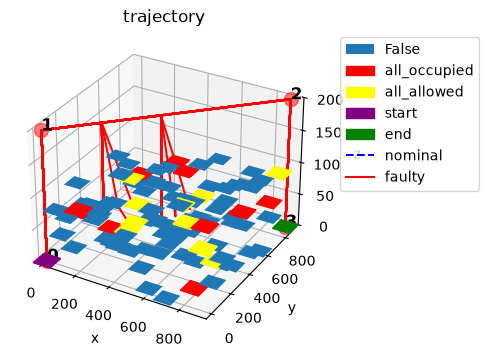

In [25]:
plot_env_with_traj_z(hists , mdl)

We can look at the results for each individual mode below. Note that by default these modes are grouped across the two injection  times.

In [26]:
statsfmea = tabulate.FMEA(endresults, fs,
                          average_metric=['rate', 'unsafe_flight_time', 'cost', 'repcost',
                                            'landcost', 'body_strikes',
                                            'head_strikes', 'property_restrictions'],
                          rates='rate')
fmeatab = statsfmea.as_table(sort_by="cost")
fmeatab

average_rate  average_unsafe_flight_time  average_cost  average_repcost  average_landcost  average_body_strikes  average_head_strikes  average_property_restrictions
drone.fxns.plan_path.ca.comps.vision undesired_detection  4.583333e-03                        0.00           0.0              0.0               0.0               0.00000                0.0000                            0.0
                                     lack_of_detection    4.583333e-03                        1.35         135.0              0.0               0.0               0.00000                0.0000                            0.0
drone.fxns.dist_ee                   degr                 2.500000e-06                       14.80        2780.0           1300.0               0.0               0.00000                0.0000                            0.0
drone.fxns.plan_path                 degloc               2.400000e-06                        0.85        1585.0           1500.0               0.0               0.00000                0.0000                            0.0
drone.fxns.ctl_dof                   degctl               2.400000e-06                        0.85        1585.0           1500.0               0.0               0.00000                0.0000                            0.0
drone.fxns.dist_ee                   short                1.500000e-06                        0.85        8985.0           1500.0            5000.0               0.00015                0.0001                            0.5
                                     break                1.000000e-06                        0.85        8985.0           1500.0            5000.0               0.00015                0.0001                            0.5
drone.fxns.affect_dof.ca.comps.lf    ctldn                1.000000e-06                        0.85        8985.0           1500.0            5000.0               0.00015                0.0001                            0.5
                                     ctlup                1.000000e-06                        0.85        8985.0           1500.0            5000.0               0.00015                0.0001                            0.5
                                     ctlbreak             1.000000e-06                        0.85        8985.0           1500.0            5000.0               0.00015                0.0001                            0.5
drone.fxns.ctl_dof                   noctl                6.000000e-07                        0.85        8985.0           1500.0            5000.0               0.00015                0.0001                            0.5
drone.fxns.plan_path                 noloc                6.000000e-07                        0.85        1585.0           1500.0               0.0               0.00000                0.0000                            0.0
drone.fxns.affect_dof.ca.comps.lf    short                5.000000e-07                        0.85        8985.0           1500.0            5000.0               0.00015                0.0001                            0.5
                                     openc                5.000000e-07                        0.85        8985.0           1500.0            5000.0               0.00015                0.0001                            0.5
                                     mechbreak            5.000000e-07                        0.85        8985.0           1500.0            5000.0               0.00015                0.0001                            0.5
drone.fxns.store_ee.ca.comps.s1p1    nocharge             3.850000e-07                        1.35         235.0            100.0               0.0               0.00000                0.0000                            0.0
drone.fxns.affect_dof.ca.comps.lf    mechfriction         2.500000e-07                        0.85        8985.0           1500.0            5000.0               0.00015                0.0001                            0.5
drone.fxns.store_ee.ca.comps.s1p1    lowchar